## Market Basket Analysis: Apriori

__Data:__ Using the publicly available Instacart Market Basket Analysis dataset

Download from: https://www.kaggle.com/competitions/instacart-market-basket-analysis/data


In [3]:
# Import packages
import pandas as pd
import random
from apyori import apriori
import matplotlib.pyplot as plt

In [4]:
# Step 1: Load the dataset
orders = pd.read_csv('orders.csv')
order_products_prior = pd.read_csv('order_products__prior.csv')
products = pd.read_csv('products.csv')

 - orders.csv: Contains metadata about each order, such as order ID, user ID, and order sequence.
 - order_products__prior.csv: Holds details of previously ordered products, linking order IDs to product IDs.
 - products.csv: Maps product IDs to product names, allowing for meaningful interpretation of transactions.

In [5]:
# Merge datasets to get product names
order_products = order_products_prior.merge(products, on='product_id', how='left')
order_products = order_products.merge(orders, on='order_id', how='left')

# Display dataset sample
display(order_products.head())

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2,33120,1,1,Organic Egg Whites,86,16,202279,prior,3,5,9,8.0
1,2,28985,2,1,Michigan Organic Kale,83,4,202279,prior,3,5,9,8.0
2,2,9327,3,0,Garlic Powder,104,13,202279,prior,3,5,9,8.0
3,2,45918,4,1,Coconut Butter,19,13,202279,prior,3,5,9,8.0
4,2,30035,5,0,Natural Sweetener,17,13,202279,prior,3,5,9,8.0


## Data Preprocessing

In [6]:
# Step 2: Data Preprocessing
# Group products by order_id to create transactions
transactions = order_products.groupby('order_id')['product_name'].apply(list).tolist()

# Create own dataset by randomly selecting transactions
random_sample = random.sample(transactions, 5000)  # Selecting 5000 transactions for analysis

# Display a sample of transactions
for i in range(5):
    print(random_sample[i])

['Mild Chunky Salsa', 'Organic Sweet Peas', 'Premium Organic Whole Kernel Sweet Corn', 'Organic 1% Milk', 'Organic Banana', 'Jade Pearl Rice Ramen', 'Roast Chicken Flavor Ramen Noodles', 'Organic Chicken Bone Broth', 'With Pineapple Pulp Free Orange Juice']
['Organic Gala Apples', 'Organic All Natural Blueberry Mini Waffles', 'Cantaloupe', 'Crazy Feta Dip', 'Super Seed Crispy Crackers', 'Organic Whole Grassmilk Milk', 'Oh My Yog! Madagascar Vanilla Trilayer Yogyurt']
['Celery Hearts', 'Organic Zucchini', 'Grade A Large White Eggs', 'Jumbo Beef Franks', 'Enriched Poppyseed Hot Dog Buns', 'Ricotta Whole Milk Cheese', 'Pronamel Gentle Whitening Toothpaste', 'Easy Cheese Cheddar Cheese', 'Original Baked Whole Grain Wheat Crackers']
['Extra Fancy Unsalted Mixed Nuts', 'Milk Chocolate Almonds', 'Hass Avocados', 'Zero Calorie Cola', 'English Muffins', 'Milk Chocolate Covered Raisins', 'Peanut Milk Chocolate XXL Bag', 'Gummy Bears']
['Tofu Miso Ramen', 'Vegan Cheddar Mac & Cheese', 'Organic Va

## Step 3: Apply Apriori Algorithm
 - Set minimum support to 0.01, minimum confidence to 0.2, and minimum lift to 1.0

In [13]:
# Step 3: Apply Apriori Algorithm
## Set minimum support to 0.01, minimum confidence to 0.2, and minimum lift to 1.0
rules = apriori(random_sample, min_support=0.01, min_confidence=0.2, min_lift=1.0, min_length=2)
rules = list(rules)
print("Association Rules Generated!")

print('Rules generated: ', len(rules))

print('First rule: ', rules[0])

Association Rules Generated!
Rules generated:  12
First rule:  RelationRecord(items=frozenset({'Organic Hass Avocado', 'Bag of Organic Bananas'}), support=0.0186, ordered_statistics=[OrderedStatistic(items_base=frozenset({'Organic Hass Avocado'}), items_add=frozenset({'Bag of Organic Bananas'}), confidence=0.3, lift=2.542372881355932)])


Change the index value [0] of 'rules[0]' to see a different rule.

## Algorithm Parameters

 - Support: How often a rule appears in transactions.
 - Confidence: The likelihood of a rule being correct.
 - Lift: Strength of a rule (>1 indicates strong association).

## Analysing the Results
Analysing the results may include checking what kind of items are featured in some of the rules. Using the method in the cell below, you can display the rules for the algorithm.

In [8]:
# Step 4: Convert Rules into a Readable Format
formatted_rules = []
for rule in rules:
    for ordered_stat in rule.ordered_statistics:
        formatted_rules.append({
            'Base': tuple(ordered_stat.items_base),
            'Add': tuple(ordered_stat.items_add),
            'Support': rule.support,
            'Confidence': ordered_stat.confidence,
            'Lift': ordered_stat.lift
        })

rules_df = pd.DataFrame(formatted_rules)
display(rules_df)

,Base,Add,Support,Confidence,Lift
0,"(Organic Hass Avocado,)","(Bag of Organic Bananas,)",0.0186,0.300000,2.542373
1,"(Organic Raspberries,)","(Bag of Organic Bananas,)",0.0112,0.285714,2.421308
2,"(Organic Strawberries,)","(Bag of Organic Bananas,)",0.0190,0.224057,1.898785
3,"(Cucumber Kirby,)","(Banana,)",0.0106,0.333333,2.354049
4,"(Large Lemon,)","(Banana,)",0.0122,0.257384,1.817683
5,"(Limes,)","(Banana,)",0.0122,0.282407,1.994403
6,"(Organic Avocado,)","(Banana,)",0.0176,0.318841,2.251699
7,"(Organic Strawberries,)","(Banana,)",0.0210,0.247642,1.748881
8,"(Organic Whole Milk,)","(Banana,)",0.0104,0.246445,1.740434
9,"(Strawberries,)","(Banana,)",0.0102,0.236111,1.667451


 - Support: How often a rule appears in transactions.
 - Confidence: The likelihood of a rule being correct.
 - Lift: Strength of a rule (>1 indicates strong association).

## Visualisation

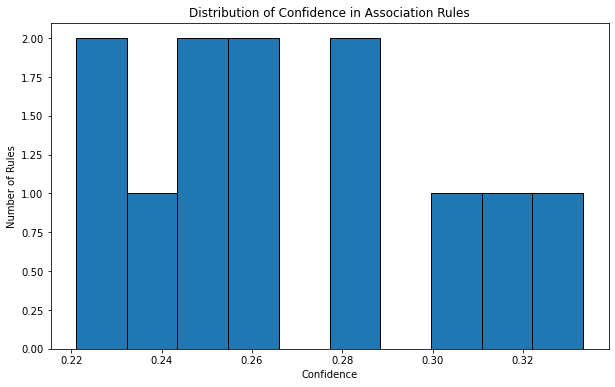

In [9]:
# Step 5: Visualizing Results
plt.figure(figsize=(10, 6))
plt.hist(rules_df['Confidence'], bins=10, edgecolor='black')
plt.xlabel('Confidence')
plt.ylabel('Number of Rules')
plt.title('Distribution of Confidence in Association Rules')
plt.show()

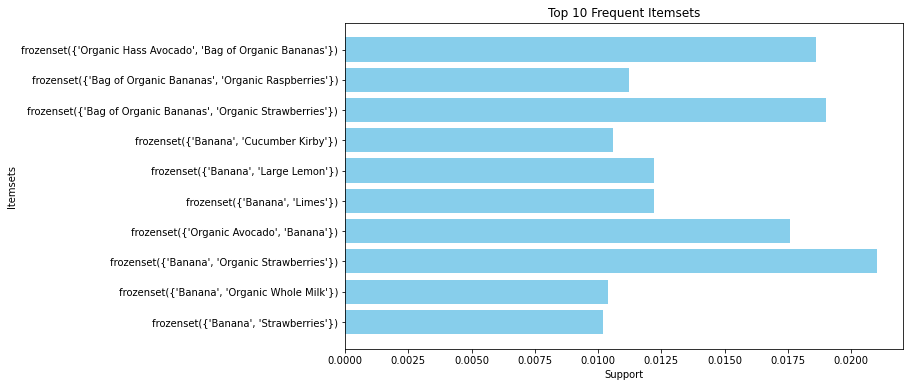

In [10]:
# Additional Visualization: Top Frequent Items
support_values = [rule.support for rule in rules]
items = [str(rule.items) for rule in rules]

plt.figure(figsize=(10, 6))
plt.barh(items[:10], support_values[:10], color='skyblue')
plt.xlabel('Support')
plt.ylabel('Itemsets')
plt.title('Top 10 Frequent Itemsets')
plt.gca().invert_yaxis()
plt.show()

## Tasks:
 - Modify the min_support, min_confidence, and min_lift values and observe the changes.
 - Randomly sample a different subset of transactions and re-run Apriori.
 - Generate different plots to analyse the effects of parameter tuning on rule generation.
 - Add explanation as required.
